# Imports

In [63]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from src.decision_tree import DecisionTreeClassifier, Node
import pandas as pd


## Load the breast cancer dataset

In [50]:
dataset = load_breast_cancer()
X=dataset.data
y=dataset.target

print("Dataset Information:")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Feature names: {dataset.feature_names}")
print(f"\nClass distribution:")
print(f"Class 0 (malignant): {np.sum(y == 0)}")
print(f"Class 1 (benign): {np.sum(y == 1)}")

Dataset Information:
Number of samples: 569
Number of features: 30
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Class distribution:
Class 0 (malignant): 212
Class 1 (benign): 357


### Data Splitting

In [51]:
X_train,X_temp,y_train,y_temp=train_test_split(X,y,test_size=0.30,stratify=y,random_state=42)
X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,test_size=0.50,stratify=y_temp,random_state=42)

print(X_train.shape)
print(y_train.shape)

(398, 30)
(398,)


### Hyperparameter tuning

In [52]:
max_depth_values = [2, 4, 6, 8, 10]
min_samples_split_values = [2, 5, 10]

# Store results
results = []

best_val_acc=0
best_params=None
best_model=None


In [54]:
for max_depth in max_depth_values:
    for min_samples_split in min_samples_split_values:
        # Train Model
        model=DecisionTreeClassifier(max_depth,min_samples_split)
        model.fit(X_train,y_train)
        
        #Evaluate
        train_pred=model.predict(X_train)
        val_pred=model.predict(X_val)
        
        train_acc = accuracy_score(y_train, train_pred)
        val_acc = accuracy_score(y_val, val_pred)
        
        results.append({
            'max_depth':max_depth,
            'min_samples_split':min_samples_split,
            'train_accuracy':train_acc,
            'validation_accuracy':val_acc
        })
        
        print(f"Max Depth: {max_depth:<2} Min samples in split: {min_samples_split:<2} Training Accuracy: {train_acc:<2.4f} Validation Accuracy: {val_acc:<2.4f}")
        
        # Track best model
        if val_acc>best_val_acc:
            best_val_acc=val_acc
            best_params=(max_depth,min_samples_split)
            best_model=model
print(f"\nBest hyperparameters: max_depth={best_params[0]}, min_samples_split={best_params[1]}")
print(f"Best validation accuracy: {best_val_acc:.4f}")

Max Depth: 2  Min samples in split: 2  Training Accuracy: 0.9523 Validation Accuracy: 0.9176
Max Depth: 2  Min samples in split: 5  Training Accuracy: 0.9523 Validation Accuracy: 0.9176
Max Depth: 2  Min samples in split: 10 Training Accuracy: 0.9523 Validation Accuracy: 0.9176
Max Depth: 4  Min samples in split: 2  Training Accuracy: 0.9925 Validation Accuracy: 0.9882
Max Depth: 4  Min samples in split: 5  Training Accuracy: 0.9925 Validation Accuracy: 0.9882
Max Depth: 4  Min samples in split: 10 Training Accuracy: 0.9899 Validation Accuracy: 0.9882
Max Depth: 6  Min samples in split: 2  Training Accuracy: 0.9950 Validation Accuracy: 0.9882
Max Depth: 6  Min samples in split: 5  Training Accuracy: 0.9950 Validation Accuracy: 0.9882
Max Depth: 6  Min samples in split: 10 Training Accuracy: 0.9925 Validation Accuracy: 0.9882
Max Depth: 8  Min samples in split: 2  Training Accuracy: 1.0000 Validation Accuracy: 0.9882
Max Depth: 8  Min samples in split: 5  Training Accuracy: 0.9950 Valid

### Retrain on Train + validation with best hyperparameter

In [55]:
X_train_full=np.vstack([X_train,X_val])
y_train_full=np.hstack([y_train,y_val])

final_model=DecisionTreeClassifier(max_depth=best_params[0],min_samples_split=best_params[1])
final_model.fit(X_train_full,y_train_full)


Final Evaluation on test set

In [56]:
y_test_pred=final_model.predict(X_test)
test_acc=accuracy_score(y_test,y_test_pred)

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8837


### Performance Metrics

In [57]:
precision_class0 = precision_score(y_test, y_test_pred, pos_label=0)
precision_class1 = precision_score(y_test, y_test_pred, pos_label=1)
recall_class0 = recall_score(y_test, y_test_pred, pos_label=0)
recall_class1 = recall_score(y_test, y_test_pred, pos_label=1)
f1_class0 = f1_score(y_test, y_test_pred, pos_label=0)
f1_class1 = f1_score(y_test, y_test_pred, pos_label=1)

print(f"Overall Accuracy: {test_acc:.4f}")
print(f"\nClass 0 (Malignant):")
print(f"  Precision: {precision_class0:.4f}")
print(f"  Recall: {recall_class0:.4f}")
print(f"  F1-Score: {f1_class0:.4f}")
print(f"\nClass 1 (Benign):")
print(f"  Precision: {precision_class1:.4f}")
print(f"  Recall: {recall_class1:.4f}")
print(f"  F1-Score: {f1_class1:.4f}")

Overall Accuracy: 0.8837

Class 0 (Malignant):
  Precision: 0.8667
  Recall: 0.8125
  F1-Score: 0.8387

Class 1 (Benign):
  Precision: 0.8929
  Recall: 0.9259
  F1-Score: 0.9091


### Confusion Matrix

Confusion Matrix


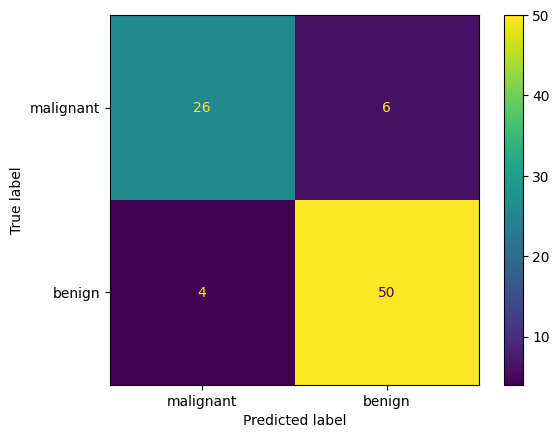

In [64]:
print("Confusion Matrix")
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["malignant","benign"])
disp.plot()
plt.show()

### Feature Importance

In [61]:
feature_imp=model.feature_importance 
feature_names=dataset.feature_names # type: ignore

# sort by importance (aka highest I.G)
imp_indices=np.argsort(feature_imp)[::-1]
print(f"10 Most important features:")
for i ,idx in enumerate(imp_indices[:10],1):
    print(f"{i}: {feature_names[idx]} {feature_imp[idx]:.4f}")


10 Most important features:
1: mean texture 0.6956
2: worst radius 0.5797
3: worst concave points 0.5450
4: worst texture 0.4777
5: worst area 0.4690
6: mean smoothness 0.4204
7: mean fractal dimension 0.3095
8: mean concavity 0.1517
9: radius error 0.0642
10: symmetry error 0.0208


### Training Accuracy vs Max Depth(Fixing the min_samples_split)

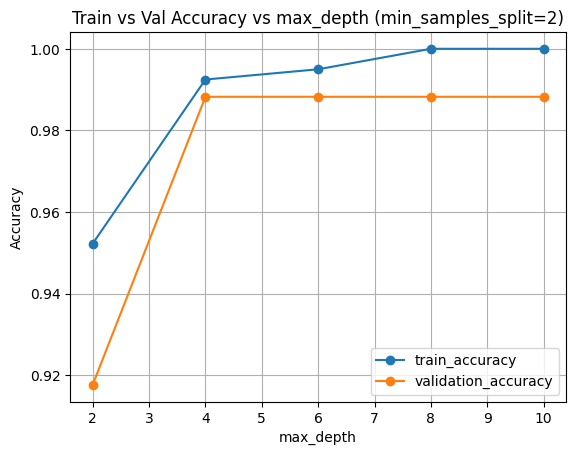

In [ ]:
results_df=pd.DataFrame(results)
rows =results_df[results_df['min_samples_split']==2].sort_values('max_depth')

plt.plot(rows['max_depth'],rows['train_accuracy'],marker='o',label='train_accuracy')
plt.plot(rows['max_depth'],rows['validation_accuracy'],marker='o',label='validation_accuracy')
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title(f"Train vs Val Accuracy vs max_depth (min_samples_split={2})")
plt.legend()
plt.grid(True)
plt.show()

### Tree Complexity

In [72]:
summary = results_df.groupby("max_depth").agg({"train_accuracy":"mean", "validation_accuracy":"mean"}).reset_index()
print(summary)


   max_depth  train_accuracy  validation_accuracy
0          2        0.952261             0.917647
1          4        0.991625             0.988235
2          6        0.994137             0.988235
3          8        0.995812             0.988235
4         10        0.995812             0.988235


It's clear that as training accuracy >> validation accuracy , overfitting occurs and that happens when depth of the tree increases
best depth is when difference between traininf accuracy and validation is small which is tree depth=4